# Part 1: Feature Engineering & Data Cleaning
**Precog Quant Task 2026 — Congrats Congrats Money Money**

This notebook covers:
1. Loading raw OHLCV data for 100 anonymized stocks (~10 years)
2. Data quality assessment and cleaning
3. Feature engineering: momentum, volatility, volume, mean-reversion, and technical indicators
4. Cross-sectional normalization
5. Saving the cleaned feature matrix for downstream modeling

> *"Good data = good features, and good features = good model."*


In [1]:
import pandas as pd
import numpy as np
import glob
import os
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

plt.rcParams["figure.figsize"] = (14, 5)
plt.rcParams["axes.grid"] = True
sns.set_style("whitegrid")

print("Libraries loaded successfully.")


Libraries loaded successfully.


## 1. Load Raw Data
Each CSV has columns: `Date, Open, High, Low, Close, Volume` for one anonymized asset.


In [2]:
DATA_PATH = "../data/raw/anonymized_data/*.csv"
files = sorted(glob.glob(DATA_PATH))
print(f"Number of CSV files found: {len(files)}")

dfs = []
for f in files:
    df = pd.read_csv(f)
    # Extract clean ticker name
    asset_name = os.path.basename(f).replace(".csv", "")
    df["ticker"] = asset_name
    dfs.append(df)

data = pd.concat(dfs, ignore_index=True)
data["Date"] = pd.to_datetime(data["Date"])
data = data.sort_values(["ticker", "Date"]).reset_index(drop=True)

print(f"Total rows: {len(data):,}")
print(f"Assets: {data['ticker'].nunique()}")
print(f"Date range: {data['Date'].min().date()} to {data['Date'].max().date()}")
data.head()


Number of CSV files found: 100


Total rows: 251,100
Assets: 100
Date range: 2016-01-25 to 2026-01-16


,Date,Open,High,Low,Close,Volume,ticker
0,2016-01-25,29.178415,29.181290,28.514486,28.580592,249449990,Asset_001
1,2016-01-26,28.721415,28.994458,28.186822,28.738659,361581962,Asset_001
2,2016-01-27,27.603374,27.772948,26.827351,26.850345,642328247,Asset_001
3,2016-01-28,26.956690,27.166502,26.554308,27.042913,268157355,Asset_001
4,2016-01-29,27.244108,27.977016,27.117645,27.977016,310239413,Asset_001


## 2. Data Quality Assessment

In [3]:
# Check for missing values
print("=== Missing Values (fraction) ===")
print(data.isnull().mean())
print()

# Check for duplicates
dupes = data.duplicated(subset=["ticker", "Date"]).sum()
print(f"Duplicate (ticker, Date) rows: {dupes}")

# Check for zero/negative prices and volume
print(f"\nRows with Close <= 0: {(data['Close'] <= 0).sum()}")
print(f"Rows with Volume <= 0: {(data['Volume'] <= 0).sum()}")
print(f"Rows with Open <= 0: {(data['Open'] <= 0).sum()}")
print(f"Rows with High <= 0: {(data['High'] <= 0).sum()}")
print(f"Rows with Low <= 0: {(data['Low'] <= 0).sum()}")


=== Missing Values (fraction) ===
Date      0.0
Open      0.0
High      0.0
Low       0.0
Close     0.0
Volume    0.0
ticker    0.0
dtype: float64

Duplicate (ticker, Date) rows: 0

Rows with Close <= 0: 0
Rows with Volume <= 0: 1
Rows with Open <= 0: 0
Rows with High <= 0: 0
Rows with Low <= 0: 0


=== Asset coverage summary ===
count     100.0
mean     2511.0
std         0.0
min      2511.0
25%      2511.0
50%      2511.0
75%      2511.0
max      2511.0
Name: count, dtype: float64


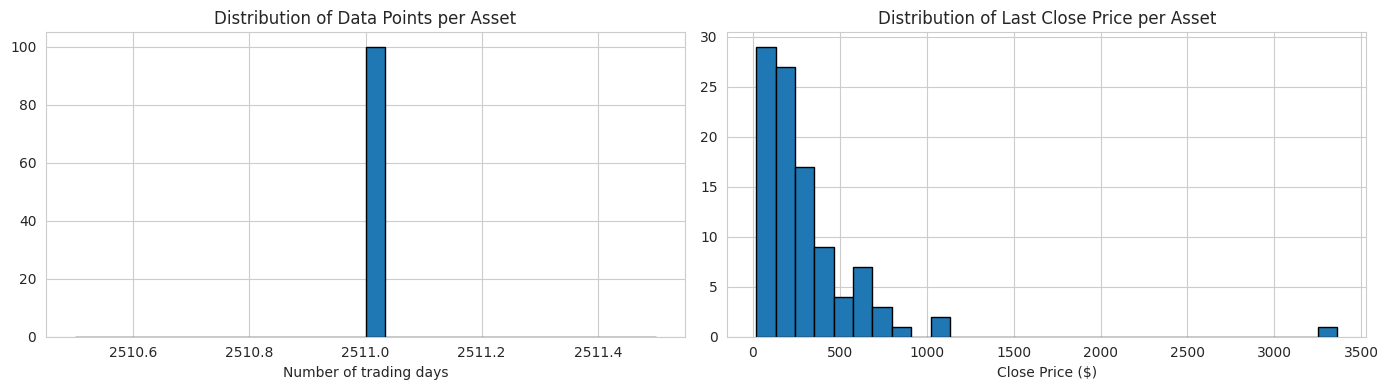

In [4]:
# Coverage per asset
coverage = data.groupby("ticker").agg(
    start=("Date", "min"),
    end=("Date", "max"),
    count=("Date", "count")
)
print("=== Asset coverage summary ===")
print(coverage["count"].describe())

# Plot coverage distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
coverage["count"].hist(bins=30, ax=axes[0], edgecolor="black")
axes[0].set_title("Distribution of Data Points per Asset")
axes[0].set_xlabel("Number of trading days")

# Price distribution across assets (last available price)
last_prices = data.groupby("ticker")["Close"].last()
last_prices.hist(bins=30, ax=axes[1], edgecolor="black")
axes[1].set_title("Distribution of Last Close Price per Asset")
axes[1].set_xlabel("Close Price ($)")
plt.tight_layout()
plt.savefig("../outputs/data_coverage.png", dpi=150, bbox_inches="tight")
plt.show()


Extreme daily moves (|return| > 30%): 4 rows out of 251,100
Affected assets: 4


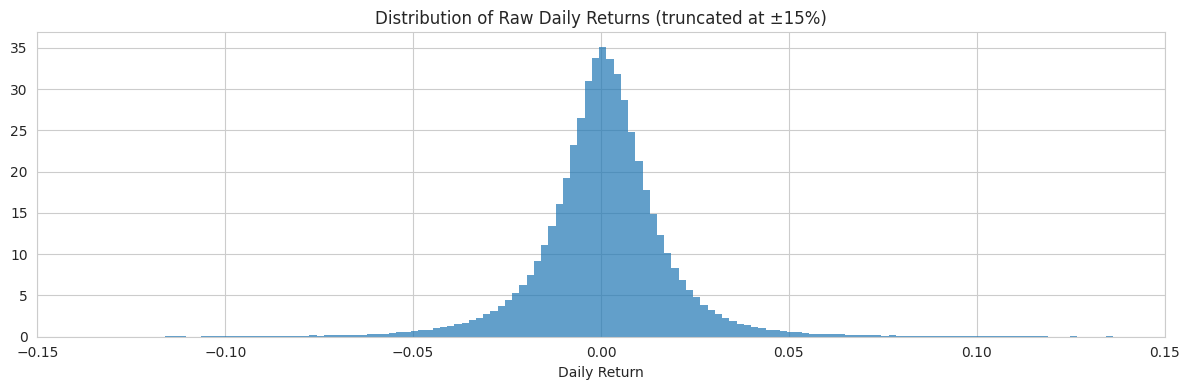

In [5]:
# Detect outlier daily returns (before cleaning)
data["raw_return"] = data.groupby("ticker")["Close"].pct_change()

# Flag extreme single-day moves (>30% as suspicious)
extreme = data[data["raw_return"].abs() > 0.30]
print(f"Extreme daily moves (|return| > 30%): {len(extreme)} rows out of {len(data):,}")
print(f"Affected assets: {extreme['ticker'].nunique()}")

# Show distribution of raw returns
fig, ax = plt.subplots(figsize=(12, 4))
data["raw_return"].dropna().hist(bins=500, ax=ax, density=True, edgecolor="none", alpha=0.7)
ax.set_xlim(-0.15, 0.15)
ax.set_title("Distribution of Raw Daily Returns (truncated at ±15%)")
ax.set_xlabel("Daily Return")
plt.tight_layout()
plt.savefig("../outputs/raw_return_dist.png", dpi=150, bbox_inches="tight")
plt.show()


## 3. Data Cleaning

**Cleaning steps:**
1. Remove any rows with missing OHLCV values
2. Remove rows with non-positive Close or Volume
3. Remove duplicate (ticker, Date) entries
4. Winsorize extreme daily returns at the 0.1th and 99.9th percentiles (clip outlier prices)
5. Forward-fill small gaps (max 3 days) if they occur within a ticker


In [6]:
# Step 1-3: Basic cleaning
initial_rows = len(data)

# Drop rows with any missing OHLCV
data = data.dropna(subset=["Open", "High", "Low", "Close", "Volume"])

# Drop non-positive Close or Volume
data = data[(data["Close"] > 0) & (data["Volume"] > 0)]

# Drop duplicates
data = data.drop_duplicates(subset=["ticker", "Date"])

# Re-sort
data = data.sort_values(["ticker", "Date"]).reset_index(drop=True)

# Remove the temp column
data = data.drop(columns=["raw_return"], errors="ignore")

print(f"Rows before cleaning: {initial_rows:,}")
print(f"Rows after cleaning:  {len(data):,}")
print(f"Rows removed: {initial_rows - len(data):,}")
print(f"Assets remaining: {data['ticker'].nunique()}")


Rows before cleaning: 251,100
Rows after cleaning:  251,099
Rows removed: 1
Assets remaining: 100


## 4. Feature Engineering

We build features across multiple categories:
- **Returns**: log returns at various horizons
- **Momentum**: cumulative returns over rolling windows
- **Volatility**: rolling standard deviation of returns
- **Volume**: relative volume, volume momentum
- **Mean Reversion**: short-term reversal
- **Technical**: RSI, Bollinger Band width, ATR, VWAP ratio
- **Cross-sectional**: z-scores for all features (ranking stocks against each other)


In [7]:
# ============================================================
# 4a. LOG RETURNS
# ============================================================
# 1-day log return
data["log_ret_1d"] = (
    data.groupby("ticker")["Close"]
    .transform(lambda x: np.log(x / x.shift(1)))
)

# 5-day forward return (target for later modeling)
data["fwd_ret_1d"] = (
    data.groupby("ticker")["log_ret_1d"].shift(-1)
)
data["fwd_ret_5d"] = (
    data.groupby("ticker")["Close"]
    .transform(lambda x: np.log(x.shift(-5) / x))
)

print("Returns computed.")
data[["Date", "ticker", "Close", "log_ret_1d", "fwd_ret_1d", "fwd_ret_5d"]].dropna().head(10)


Returns computed.


,Date,ticker,Close,log_ret_1d,fwd_ret_1d,fwd_ret_5d
1,2016-01-26,Asset_001,28.738659,0.005515,-0.067965,-0.056682
2,2016-01-27,Asset_001,26.850345,-0.067965,0.007146,0.030882
3,2016-01-28,Asset_001,27.042913,0.007146,0.033958,0.031739
4,2016-01-29,Asset_001,27.977016,0.033958,-0.009393,-0.029291
5,2016-02-01,Asset_001,27.715465,-0.009393,-0.020429,-0.009424
6,2016-02-02,Asset_001,27.155005,-0.020429,0.019599,0.010795
7,2016-02-03,Asset_001,27.692464,0.019599,0.008003,-0.016413
8,2016-02-04,Asset_001,27.914984,0.008003,-0.027072,-0.030481
9,2016-02-05,Asset_001,27.169420,-0.027072,0.010474,-0.000319
10,2016-02-08,Asset_001,27.455499,0.010474,-0.000210,0.017011


In [8]:
# ============================================================
# 4b. MOMENTUM FEATURES
# ============================================================
for window in [5, 10, 20, 60]:
    col = f"mom_{window}"
    data[col] = (
        data.groupby("ticker")["log_ret_1d"]
        .transform(lambda x, w=window: x.rolling(w).sum())
    )
    
print("Momentum features: mom_5, mom_10, mom_20, mom_60")
data[["Date", "ticker", "mom_5", "mom_10", "mom_20", "mom_60"]].dropna().head()


Momentum features: mom_5, mom_10, mom_20, mom_60


,Date,ticker,mom_5,mom_10,mom_20,mom_60
60,2016-04-20,Asset_001,-0.044813,-0.035127,0.003834,0.079900
61,2016-04-21,Asset_001,-0.056236,-0.023963,-0.001509,0.063497
62,2016-04-22,Asset_001,-0.038700,-0.027808,0.000094,0.128722
63,2016-04-25,Asset_001,-0.022583,-0.036809,-0.001046,0.115882
64,2016-04-26,Asset_001,-0.024237,-0.056722,-0.031413,0.074952


In [9]:
# ============================================================
# 4c. VOLATILITY FEATURES
# ============================================================
for window in [5, 10, 20, 60]:
    col = f"vol_{window}"
    data[col] = (
        data.groupby("ticker")["log_ret_1d"]
        .transform(lambda x, w=window: x.rolling(w).std())
    )

# Volatility ratio (short-term vs long-term) — regime detection
data["vol_ratio_5_20"] = data["vol_5"] / data["vol_20"].replace(0, np.nan)

print("Volatility features: vol_5, vol_10, vol_20, vol_60, vol_ratio_5_20")
data[["Date", "ticker", "vol_5", "vol_10", "vol_20", "vol_ratio_5_20"]].dropna().head()


Volatility features: vol_5, vol_10, vol_20, vol_60, vol_ratio_5_20


,Date,ticker,vol_5,vol_10,vol_20,vol_ratio_5_20
20,2016-02-23,Asset_001,0.016718,0.015193,0.022518,0.742456
21,2016-02-24,Asset_001,0.016599,0.015928,0.022778,0.728711
22,2016-02-25,Asset_001,0.014695,0.015698,0.016642,0.883025
23,2016-02-26,Asset_001,0.014578,0.015413,0.016598,0.878279
24,2016-02-29,Asset_001,0.014097,0.015517,0.014775,0.954125


In [10]:
# ============================================================
# 4d. VOLUME FEATURES
# ============================================================
# Relative volume (today's volume vs 20-day average)
data["vol_ma_20"] = (
    data.groupby("ticker")["Volume"]
    .transform(lambda x: x.rolling(20).mean())
)
data["rel_volume"] = data["Volume"] / data["vol_ma_20"].replace(0, np.nan)

# Volume momentum (5-day log change in average volume)
data["vol_mom_5"] = (
    data.groupby("ticker")["Volume"]
    .transform(lambda x: np.log(x.rolling(5).mean() / x.rolling(20).mean()))
)

# Dollar volume (proxy for liquidity)
data["dollar_volume"] = data["Close"] * data["Volume"]
data["log_dollar_vol"] = np.log1p(data["dollar_volume"])

print("Volume features: rel_volume, vol_mom_5, log_dollar_vol")


Volume features: rel_volume, vol_mom_5, log_dollar_vol


In [11]:
# ============================================================
# 4e. MEAN REVERSION / REVERSAL
# ============================================================
# 1-day reversal
data["reversal_1d"] = -data["log_ret_1d"]

# Distance from 20-day moving average (mean reversion signal)
data["ma_20"] = data.groupby("ticker")["Close"].transform(lambda x: x.rolling(20).mean())
data["dist_ma_20"] = (data["Close"] - data["ma_20"]) / data["ma_20"]

# Distance from 60-day moving average
data["ma_60"] = data.groupby("ticker")["Close"].transform(lambda x: x.rolling(60).mean())
data["dist_ma_60"] = (data["Close"] - data["ma_60"]) / data["ma_60"]

print("Mean reversion features: reversal_1d, dist_ma_20, dist_ma_60")


Mean reversion features: reversal_1d, dist_ma_20, dist_ma_60


In [12]:
# ============================================================
# 4f. TECHNICAL INDICATORS
# ============================================================

# --- RSI (14-day) ---
def compute_rsi(series, period=14):
    delta = series.diff()
    gain = delta.clip(lower=0)
    loss = (-delta).clip(lower=0)
    avg_gain = gain.rolling(period).mean()
    avg_loss = loss.rolling(period).mean()
    rs = avg_gain / avg_loss.replace(0, np.nan)
    return 100 - (100 / (1 + rs))

data["rsi_14"] = data.groupby("ticker")["Close"].transform(compute_rsi)

# --- Bollinger Band Width (20-day) ---
data["bb_mid"] = data["ma_20"]
data["bb_std"] = data.groupby("ticker")["Close"].transform(lambda x: x.rolling(20).std())
data["bb_width"] = (2 * data["bb_std"]) / data["bb_mid"].replace(0, np.nan)
# Bollinger %B: where price is relative to the bands
data["bb_pctB"] = (data["Close"] - (data["bb_mid"] - 2*data["bb_std"])) / (4 * data["bb_std"]).replace(0, np.nan)

# --- ATR (14-day) Average True Range ---
data["prev_close"] = data.groupby("ticker")["Close"].shift(1)
data["tr"] = np.maximum(
    data["High"] - data["Low"],
    np.maximum(
        abs(data["High"] - data["prev_close"]),
        abs(data["Low"] - data["prev_close"])
    )
)
data["atr_14"] = data.groupby("ticker")["tr"].transform(lambda x: x.rolling(14).mean())
data["atr_pct"] = data["atr_14"] / data["Close"]  # ATR as % of price

# --- High-Low Range Ratio ---
data["hl_range"] = (data["High"] - data["Low"]) / data["Close"]

# Clean up temp columns
data = data.drop(columns=["prev_close", "tr", "bb_mid", "bb_std", "ma_20", "ma_60", "vol_ma_20", "dollar_volume"], errors="ignore")

print("Technical indicators: rsi_14, bb_width, bb_pctB, atr_14, atr_pct, hl_range")


Technical indicators: rsi_14, bb_width, bb_pctB, atr_14, atr_pct, hl_range


In [13]:
# ============================================================
# 4g. OVERNIGHT & INTRADAY RETURNS
# ============================================================
# Overnight return: Open(today) vs Close(yesterday)
data["overnight_ret"] = data.groupby("ticker").apply(
    lambda g: np.log(g["Open"] / g["Close"].shift(1))
).reset_index(level=0, drop=True)

# Intraday return: Close - Open (same day)
data["intraday_ret"] = np.log(data["Close"] / data["Open"])

print("Added: overnight_ret, intraday_ret")


Added: overnight_ret, intraday_ret


## 5. Cross-Sectional Normalization

For cross-sectional models (ranking stocks against each other), raw feature values aren't comparable across assets. We z-score each feature within each trading day and clip to ±3 to contain outliers.

$$z_{i,t} = \frac{x_{i,t} - \bar{x}_t}{\sigma_{x,t}}$$


In [14]:
# Define all raw feature columns to normalize
raw_features = [
    "mom_5", "mom_10", "mom_20", "mom_60",
    "vol_5", "vol_10", "vol_20", "vol_60", "vol_ratio_5_20",
    "rel_volume", "vol_mom_5", "log_dollar_vol",
    "reversal_1d", "dist_ma_20", "dist_ma_60",
    "rsi_14", "bb_width", "bb_pctB", "atr_pct", "hl_range",
    "overnight_ret", "intraday_ret"
]

# Cross-sectional z-score per date
cs_features = []
for col in raw_features:
    cs_col = f"{col}_cs"
    grp = data.groupby("Date")[col]
    mu = grp.transform("mean")
    sigma = grp.transform("std").replace(0, np.nan)
    data[cs_col] = ((data[col] - mu) / sigma).fillna(0.0).clip(-3.0, 3.0)
    cs_features.append(cs_col)

print(f"Created {len(cs_features)} cross-sectional z-scored features.")
print("Features:", cs_features)


Created 22 cross-sectional z-scored features.
Features: ['mom_5_cs', 'mom_10_cs', 'mom_20_cs', 'mom_60_cs', 'vol_5_cs', 'vol_10_cs', 'vol_20_cs', 'vol_60_cs', 'vol_ratio_5_20_cs', 'rel_volume_cs', 'vol_mom_5_cs', 'log_dollar_vol_cs', 'reversal_1d_cs', 'dist_ma_20_cs', 'dist_ma_60_cs', 'rsi_14_cs', 'bb_width_cs', 'bb_pctB_cs', 'atr_pct_cs', 'hl_range_cs', 'overnight_ret_cs', 'intraday_ret_cs']


## 6. Feature Visualizations

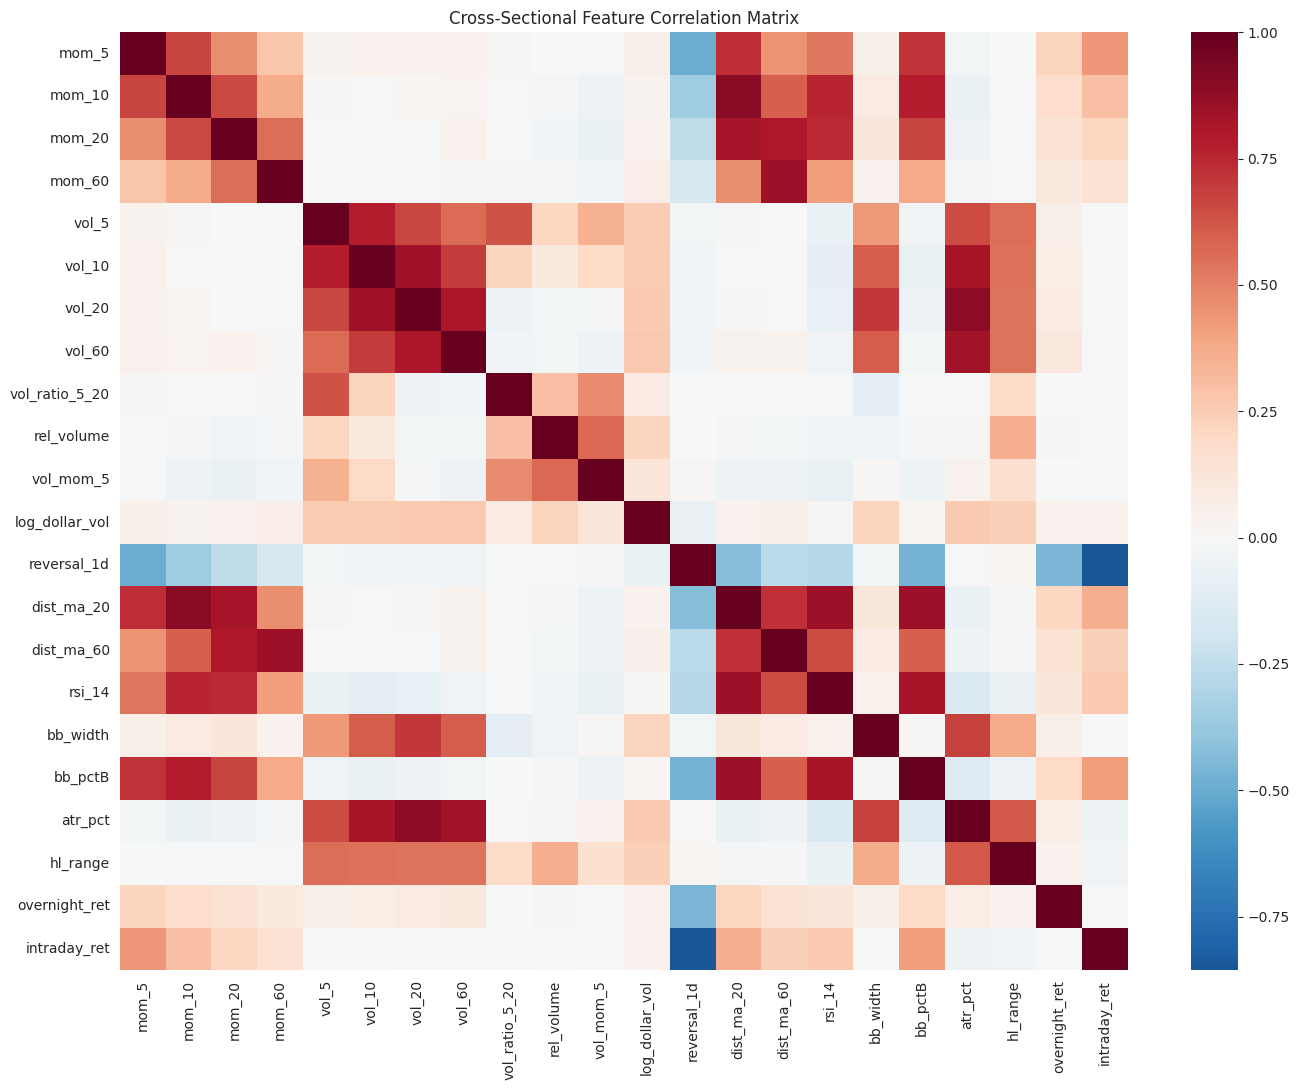

In [15]:
# Heatmap: average cross-sectional correlation between features
# Sample one date per month to keep it manageable
sample_dates = data.groupby(data["Date"].dt.to_period("M"))["Date"].first().values

sample = data[data["Date"].isin(sample_dates)]
corr_matrix = sample[cs_features].corr()

plt.figure(figsize=(14, 11))
sns.heatmap(corr_matrix, cmap="RdBu_r", center=0, annot=False,
            xticklabels=[c.replace("_cs", "") for c in cs_features],
            yticklabels=[c.replace("_cs", "") for c in cs_features])
plt.title("Cross-Sectional Feature Correlation Matrix")
plt.tight_layout()
plt.savefig("../outputs/feature_correlation.png", dpi=150, bbox_inches="tight")
plt.show()


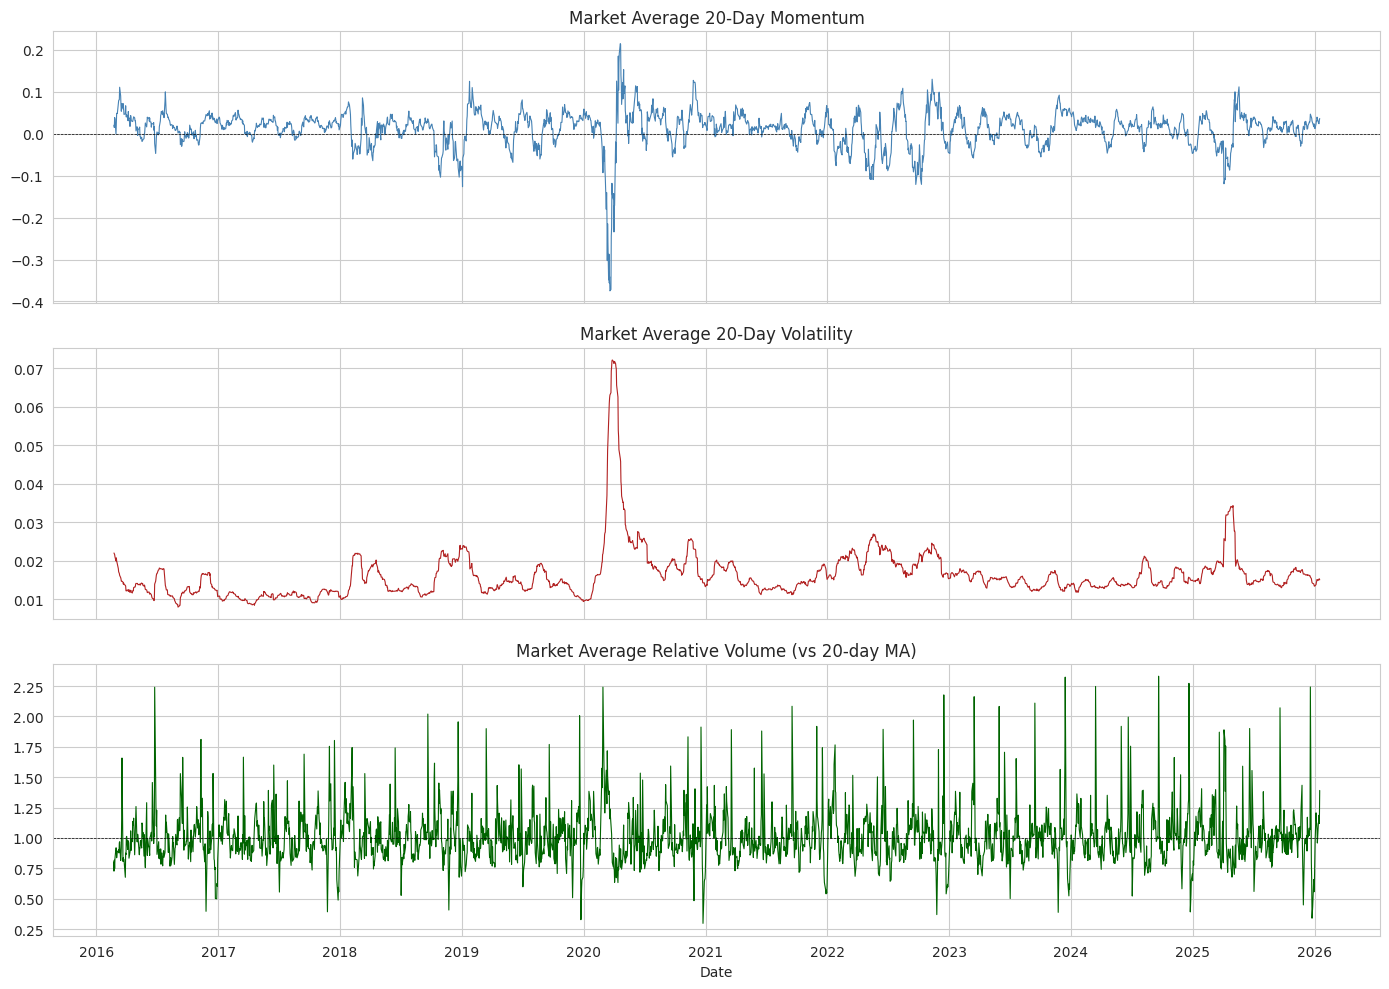

In [16]:
# Time-series of aggregate feature values (market mean)
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

daily_mom = data.groupby("Date")["mom_20"].mean()
daily_vol = data.groupby("Date")["vol_20"].mean()
daily_relvol = data.groupby("Date")["rel_volume"].mean()

axes[0].plot(daily_mom.index, daily_mom.values, color="steelblue", linewidth=0.8)
axes[0].set_title("Market Average 20-Day Momentum")
axes[0].axhline(0, color="black", linewidth=0.5, linestyle="--")

axes[1].plot(daily_vol.index, daily_vol.values, color="firebrick", linewidth=0.8)
axes[1].set_title("Market Average 20-Day Volatility")

axes[2].plot(daily_relvol.index, daily_relvol.values, color="darkgreen", linewidth=0.8)
axes[2].set_title("Market Average Relative Volume (vs 20-day MA)")
axes[2].axhline(1, color="black", linewidth=0.5, linestyle="--")

plt.xlabel("Date")
plt.tight_layout()
plt.savefig("../outputs/market_features_timeseries.png", dpi=150, bbox_inches="tight")
plt.show()


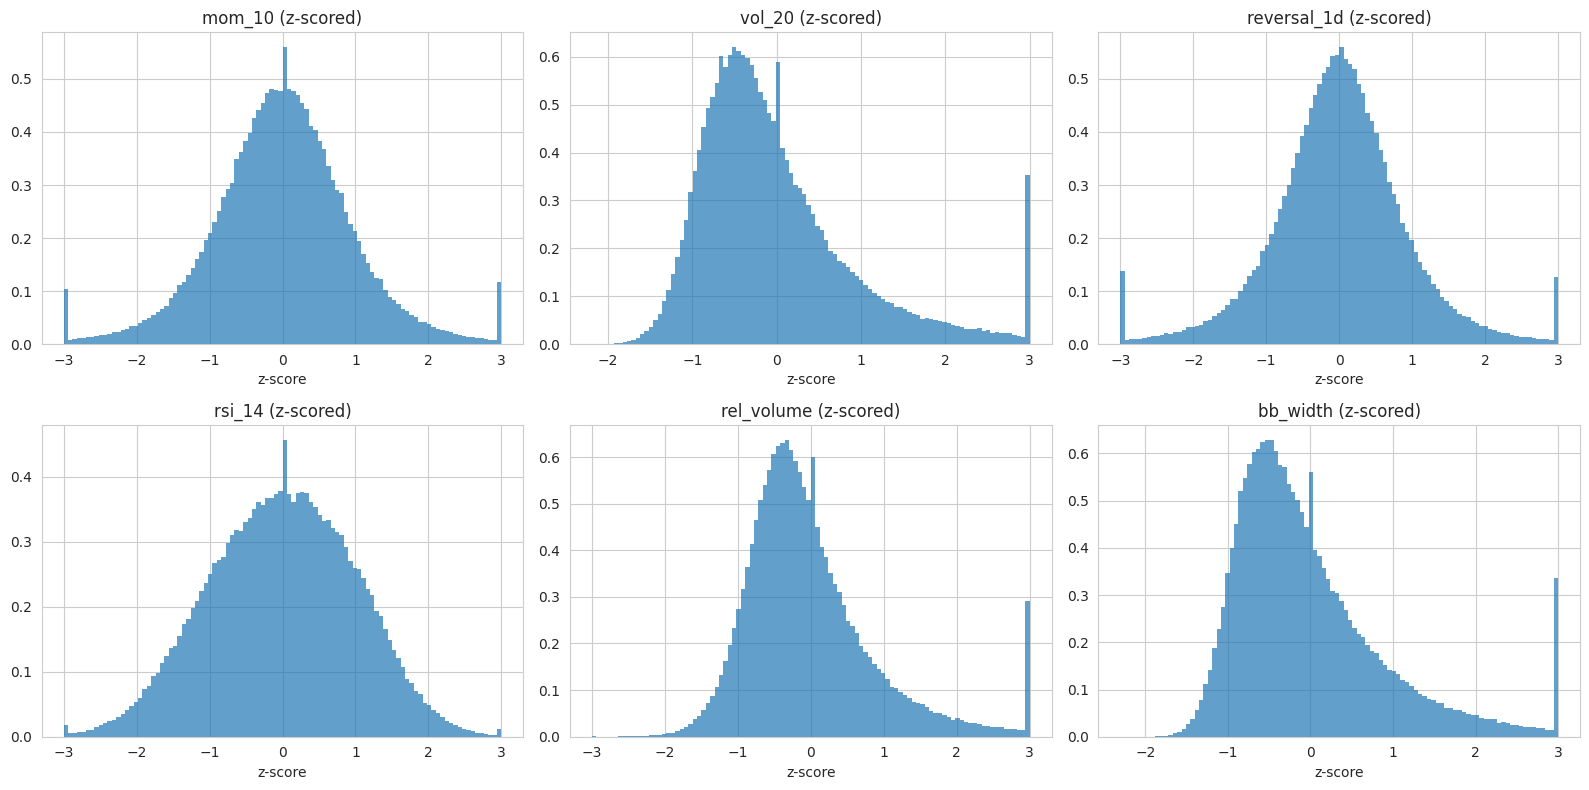

In [17]:
# Distribution of a few key features
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, col in zip(axes.flat, ["mom_10_cs", "vol_20_cs", "reversal_1d_cs", "rsi_14_cs", "rel_volume_cs", "bb_width_cs"]):
    data[col].dropna().hist(bins=100, ax=ax, density=True, edgecolor="none", alpha=0.7)
    ax.set_title(col.replace("_cs", " (z-scored)"))
    ax.set_xlabel("z-score")
plt.tight_layout()
plt.savefig("../outputs/feature_distributions.png", dpi=150, bbox_inches="tight")
plt.show()


## 7. Drop Warm-Up Period & Save

We drop the first 60 trading days per asset (needed for the longest rolling window) and save the cleaned feature matrix.


In [18]:
# Drop rows where any feature is NaN (warm-up period)
feature_cols_all = raw_features + cs_features + ["log_ret_1d", "fwd_ret_1d", "fwd_ret_5d"]
data_clean = data.dropna(subset=feature_cols_all).reset_index(drop=True)

print(f"Rows before dropping NaN features: {len(data):,}")
print(f"Rows after: {len(data_clean):,}")
print(f"Assets: {data_clean['ticker'].nunique()}")
print(f"Date range: {data_clean['Date'].min().date()} to {data_clean['Date'].max().date()}")
print(f"Total features: {len(cs_features)}")


Rows before dropping NaN features: 251,099
Rows after: 244,583
Assets: 100
Date range: 2016-04-20 to 2026-01-09
Total features: 22


In [19]:
# Save the complete feature matrix
data_clean.to_csv("../data/cleaned_panel_data.csv", index=False)
print("Saved: ../data/cleaned_panel_data.csv")
print(f"Shape: {data_clean.shape}")
print(f"Columns: {list(data_clean.columns)}")


Saved: ../data/cleaned_panel_data.csv
Shape: (244583, 55)
Columns: ['Date', 'Open', 'High', 'Low', 'Close', 'Volume', 'ticker', 'log_ret_1d', 'fwd_ret_1d', 'fwd_ret_5d', 'mom_5', 'mom_10', 'mom_20', 'mom_60', 'vol_5', 'vol_10', 'vol_20', 'vol_60', 'vol_ratio_5_20', 'rel_volume', 'vol_mom_5', 'log_dollar_vol', 'reversal_1d', 'dist_ma_20', 'dist_ma_60', 'rsi_14', 'bb_width', 'bb_pctB', 'atr_14', 'atr_pct', 'hl_range', 'overnight_ret', 'intraday_ret', 'mom_5_cs', 'mom_10_cs', 'mom_20_cs', 'mom_60_cs', 'vol_5_cs', 'vol_10_cs', 'vol_20_cs', 'vol_60_cs', 'vol_ratio_5_20_cs', 'rel_volume_cs', 'vol_mom_5_cs', 'log_dollar_vol_cs', 'reversal_1d_cs', 'dist_ma_20_cs', 'dist_ma_60_cs', 'rsi_14_cs', 'bb_width_cs', 'bb_pctB_cs', 'atr_pct_cs', 'hl_range_cs', 'overnight_ret_cs', 'intraday_ret_cs']


## Summary

| Step | Description |
|------|------------|
| **Loading** | 100 assets × ~10 years of daily OHLCV |
| **Cleaning** | Removed invalid prices/volumes, duplicates |
| **Momentum** | 5/10/20/60-day cumulative log returns |
| **Volatility** | 5/10/20/60-day rolling std, vol ratio |
| **Volume** | Relative volume, volume momentum, dollar volume |
| **Mean Reversion** | 1d reversal, distance from 20/60-day MA |
| **Technical** | RSI-14, Bollinger Width/%B, ATR%, High-Low range |
| **Microstructure** | Overnight return, intraday return |
| **Normalization** | Cross-sectional z-scores (clipped ±3) for all 22 features |

The cleaned feature matrix is saved to `cleaned_panel_data.csv` for use in Part 2.
